In [4]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

#Importation des fichiers contenant les fonctions du projet
from seamcarving_affichage import *
from seamcarving_energie import *
from seamcarving_action import *

C:\Users\dauti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Seam Carving

Le seam carving est une méthode de réduction d'image qui préserve les zones visuellement importantes.  
Elle supprime les chemins de pixels (seams) de plus faible énergie pour réduire la largeur sans déformer le contenu principal.
Ce cahier Jupiter illustre nos résultats obtenus basé sur le papier "Seam Carving for Content-Aware Image Resizing" de Shai Avidan et Ariel Shamir.

In [50]:
path = "Dataset_images/Dataset/mongolfiere.jpg"
image_rgb = plt.imread(path) #image RGB
image_gris = np.mean(image_rgb, axis=2)  # image en niveaux de gris

Nous allons commencer par afficher l'image que nous allons raccourcir

Taille de l'image: (667, 1000, 3)


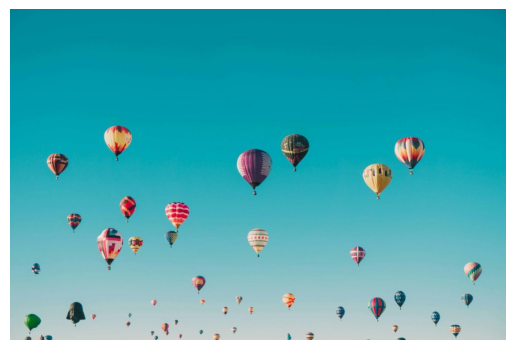

In [51]:
affichage(image_rgb,1)

La première chose à faire est de calculer l'énergie de l'image. pour cela nous avons créer une fonction __energy_basic__ qui calcule la carte d’énergie d’une image en niveaux de gris selon l'équation $e_1(I) = |\frac{\partial I}{\partial x}| + |\frac{\partial I}{\partial y}|$

Taille de l'image: (667, 1000)


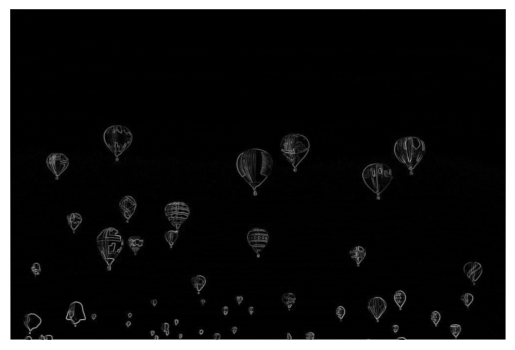

In [55]:
Mat_energie = energy_basic(image_gris)
affichage(Mat_energie,0)

Notre but est d'enlever le chemin de moindre énergie de l'image. Pour cela nous allons utilsier la fonction __creat_mat_energy_v__  qui permet de trouver le chemin de seam ayant la plus faible énergie totale à supprimer dans l’image.

Pour cela, on utilise un eméthode de programmation dynamique. La fonction va partir d'une extrémite de l'image et remonter vers l'autre. A chaque tour, elle choisira le pixel ayant le moins d'énergie parmi les 3 pixels adjacents. Enfin elle remplace la valeur du pixel par la somme totale d'énergie enlevée jusqu'à présent. Une fois arrivé à l'autre extrémité, il suffira de choisir le pixel ayant le moins d'énergie, puisque celui-ci indiquera l'énergie totale enlevée par ce chemin. Nous utiliserons donc à chaque tour cette équation: $$ M(i, j) = e(i, j) + \min \big( M(i-1, j-1),\ M(i-1, j),\ M(i-1, j+1) \big) $$

Taille de l'image: (667, 1000)


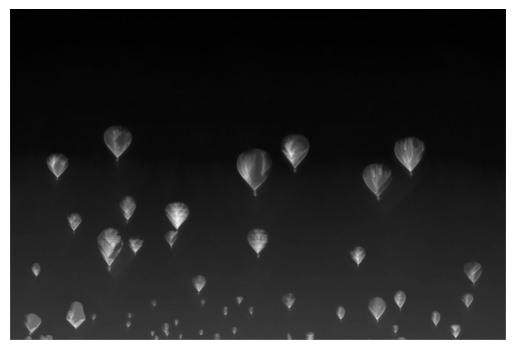

In [56]:
mat_energy_V = creat_mat_energy_V(Mat_energie)
affichage(mat_energy_V,0)

Nous vous proposons d'observer les 100 premières seam choisie par l'algorithme

Taille de l'image: (667, 1000, 3)


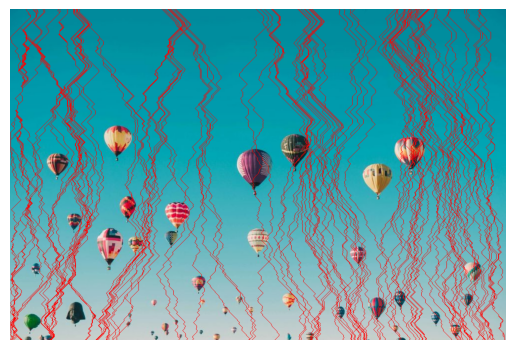

In [58]:
seams = toutes_seams(image_rgb, 100)
img_seam_show = dessiner_seams(image_rgb, seams)

affichage(img_seam_show, 1)

Nous pouvons maintenant observer le résultat de notre algorithme. Il est possible de réduire l'image verticalement avec la fonction __reduction_V__() horizontalement avec la fonction __reduction_H__().

Taille de l'image: (667, 1000, 3)


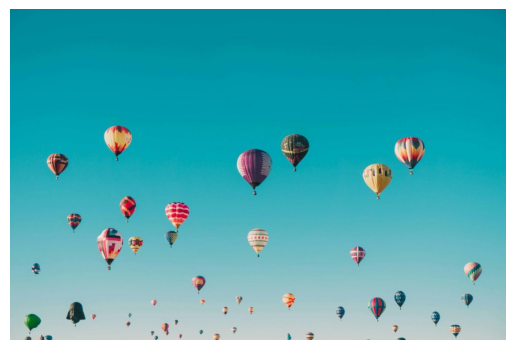

Taille de l'image: (667, 700, 3)


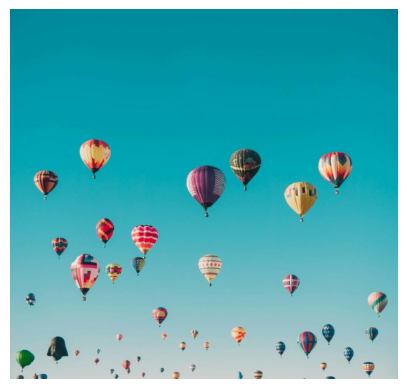

In [59]:
nb_seam_V = 300 #nombre de colonne à enlever.

image_reduite_V, _ = reduction_V(image_rgb, nb_seam_V)
affichage(image_rgb,1)
affichage(image_reduite_V,2)

Taille de l'image: (667, 1000, 3)


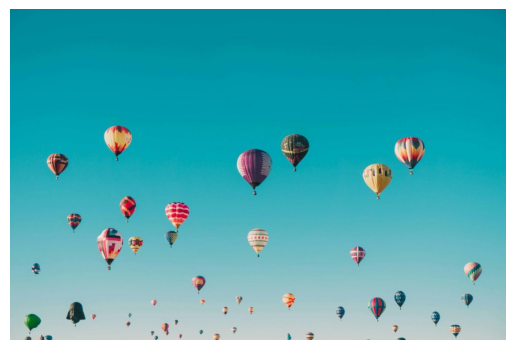

Taille de l'image: (467, 1000, 3)


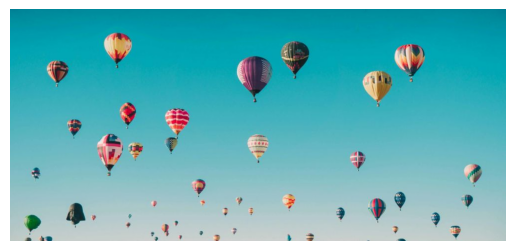

In [60]:
nb_seam_H = 200 #nombre de ligne à enlever.

image_reduite_H, _ = reduction_H(image_rgb, nb_seam_H)
affichage(image_rgb,1)
affichage(image_reduite_H,2)

Taille de l'image: (667, 1000, 3)


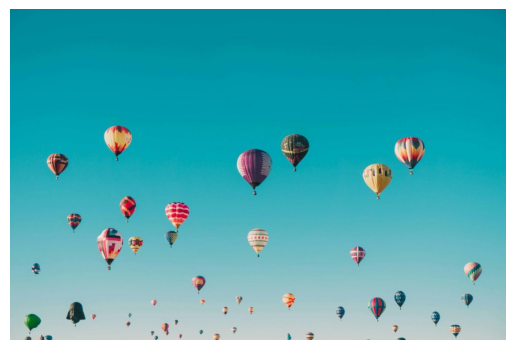

Taille de l'image: (667, 1300, 3)


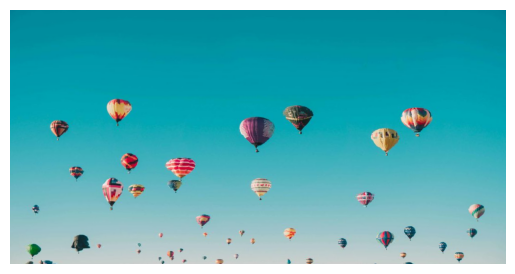

In [61]:
nb_seam_V_ajout = 300 #nombre de colonne à ajouter
image_agrandi = agrandir_V(image_rgb, nb_seam_V_ajout)
affichage(image_rgb,1)
affichage(image_agrandi,1)

Taille de l'image: (667, 1000, 3)


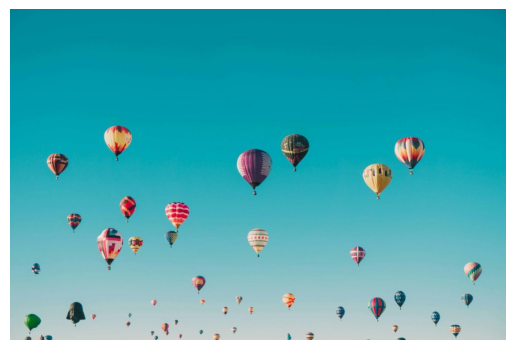

Taille de l'image: (867, 1000, 3)


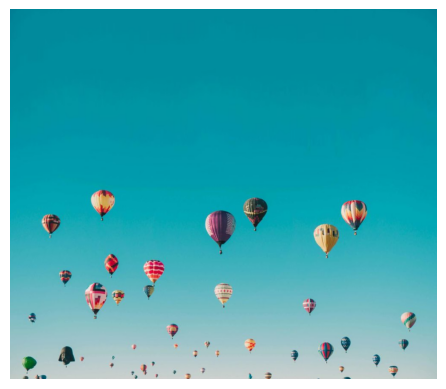

In [62]:
nb_seam_H_ajout = 200 #nombre de colonne à ajouter
image_agrandi = agrandir_H(image_rgb, nb_seam_H_ajout)
affichage(image_rgb,1)
affichage(image_agrandi,1)

Le papier propose également de pouvoir enlever des lignes et des colonnes à une image. La première méthode évoquées consiste à enlever d'abord toutes les lignes puis toutes les colonnes de l'image. cependant agir de la sorte n'est pas la méthode optimale. En choississant un ordre précis de suppression des lignes et des colonnes, il est possible de réduire l'énergie totale enlevée. Pour cela, nous avons créer une fonction __T( )__ (nom identique au papier) qui renvoie l'odre précis des seams à enlever. Nous pouvons alors comparer l'énergie totale supprimée de l'image en fonction du nombre de seam enlevé pour différentes méthodes.

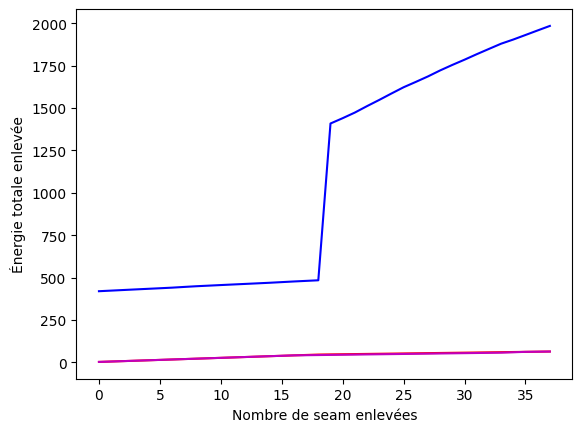

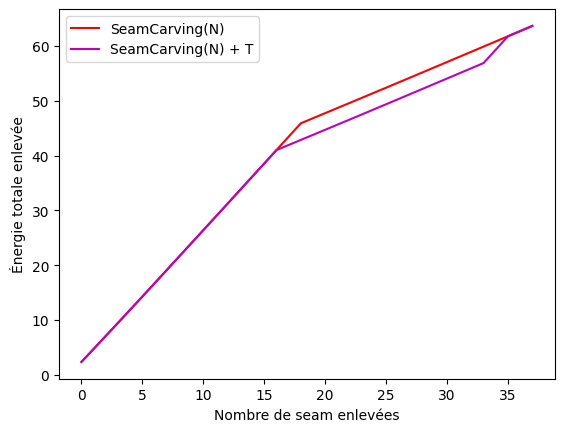

In [63]:
comparaison(20,20,image_rgb,image_gris)

Une autre métrique que nous pouvons utiliser est la __saillance__. C'est une carte d’importance visuelle où chaque pixel a une valeur qui indique à quel point ce pixel est important. Plus la différence de saillance est faible, plus l'image est proche de l'originale. On remarque que la saillance de l'image réduite par Seam Carving est plus faible que par resize.

C:\Users\dauti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\dauti\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Diff. moyenne de saillance (carving) : 0.00377
Diff. moyenne de saillance (resize)  : 0.00392


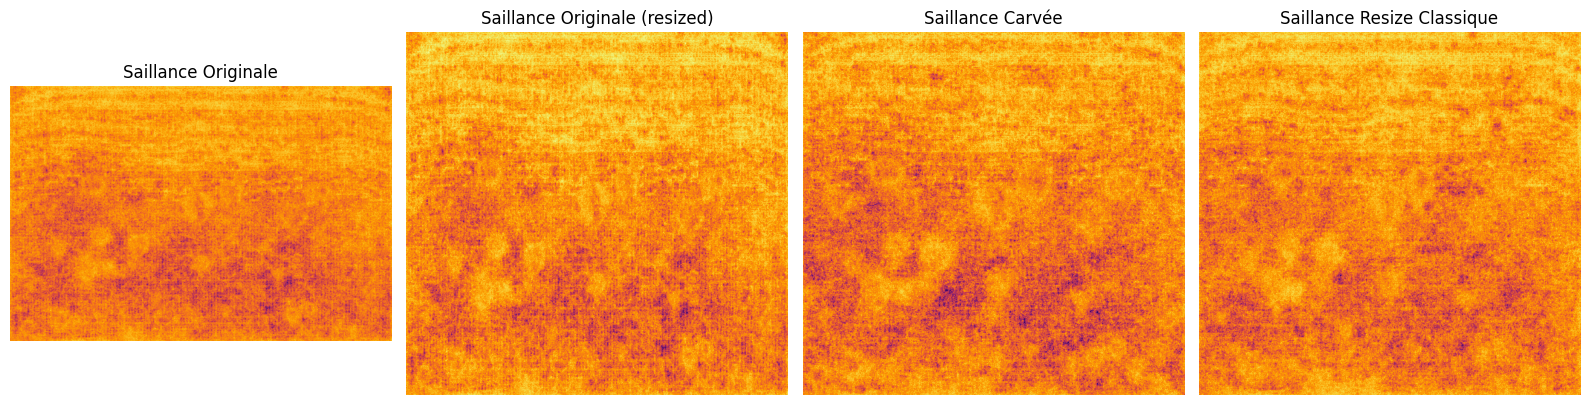

In [64]:
saillance_comparaison(image_rgb, image_reduite_V)